In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('indian_names.txt', 'r').read().lower().splitlines()
words[:8]

['aaban',
 'aabharan',
 'aabhas',
 'aabhat',
 'aabheer',
 'abheer',
 'aabher',
 'aabi']

In [3]:
len(words)

53982

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([390591, 3]) torch.Size([390591])
torch.Size([48694, 3]) torch.Size([48694])
torch.Size([48789, 3]) torch.Size([48789])


In [6]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
#we multiply ariables with some values to make the logits near 0 so we dont get false confidence and random loss

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g) #`C` is a 27×10 lookup table where each row 
                                                               #stores a 10-dimensional feature vector representing a specific character.

W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) #* 0.2
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [7]:
# =====================================================================
# THE GOAL: INITIALIZATION SCALING
# =====================================================================
# When you build a neural network, how you set your starting weights 
# matters immensely. As data moves layer by layer, we must keep the 
# signals healthy, stable, and inside a predictable range.
#
# =====================================================================
# THE PROBLEM: VARIANCE EXPANSION
# =====================================================================
# Imagine multiplying a set of numbers by random weights over and over.
# - If your weights are just slightly too large, the numbers will explode 
#   into massive values.
# - If your weights are slightly too small, the numbers will vanish 
#   into near-zero values.
#
# Mathematically, the variance (the spread of the numbers) changes 
# drastically at every single layer. This completely breaks the training 
# process before it even starts.
#
# =====================================================================
# THE SOLUTION: KAIMING INITIALIZATION (HE INIT)
# =====================================================================
# To keep the spread of your data stable (ideally a Standard Gaussian 
# distribution with a mean of 0 and a variance of 1), you scale the weights.
# 
# - Calculate the "fan-in" (the number of input connections/neurons feeding 
#   into this specific layer).
# - Divide your random weights by the square root of this fan-in number.
# - This clever mathematical balancing act ensures the output's standard 
#   deviation stays close to 1.0 from layer to layer.
#
# =====================================================================
# ACTIVATION FUNCTIONS AND THE NEED FOR "GAIN"
# =====================================================================
# Activation functions like Tanh are "contractive"—meaning they aggressively 
# squash large inputs down into a narrow range (-1 to 1). 
#
# This squashing action shrinks the variance of your signal, making it 
# weaker as it passes through the layer.
#
# To fight this, researchers introduced a "Gain" factor:
# - For the Tanh function, the mathematically proven optimal gain is 5/3 
#   (approximately 1.667).
# - You multiply your scaled weights by this 5/3 gain factor.
# - This gives the weights a slight "boost" just big enough to cancel out 
#   Tanh's squashing effect, keeping the activation flow healthy and 
#   alive even in very deep networks.
# =====================================================================


tensor(0.0105) tensor(1.0037)
tensor(0.0001) tensor(1.0121)


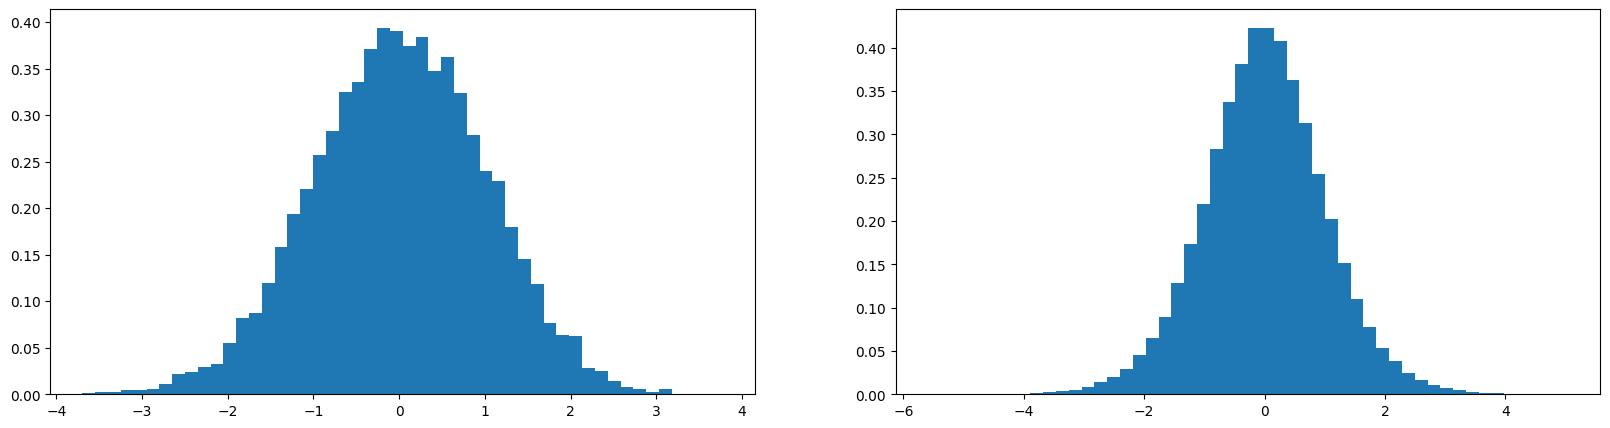

In [8]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);


In [11]:
# WHAT IS BATCH NORMALIZATION (BN)?

# Think of it as a tool that "cleans up" data inside your neural network.
# 
# As data flows through deep layers, the numbers can get wildly large or incredibly small. This messes up the training process.
# Batch Normalization steps in to keep these numbers in a stable,  predictable range so the network can learn much faster.
#
# THE 3-STEP IMPLEMENTATION
#
# STEP 1: FIND THE AVERAGE (MEAN) AND VARIANCE
# --------------------------------------------
# Look at the current batch of data going through a layer.
# - Calculate the average (mean) value for each feature/neuron.
# - Calculate the variance (how spread out the numbers are).
#
# STEP 2: STANDARDIZE THE NUMBERS
# --------------------------------
# - Take every number, subtract the average, and divide by the spread.
# - Add a tiny number (called "epsilon" or "eps") before dividing so you never accidentally divide by zero.
# - Result: Your data now has an average of 0 and a spread of 1.
#
# STEP 3: GIVE THE NETWORK FLEXIBILITY (SCALE & SHIFT)
# ----------------------------------------------------
# Forcing everything to have an average of 0 and spread of 1 can be too restrictive. The network might actually *need* different ranges.
# - Introduce two trainable parameters:     gain  Gamma (scale)     and      bias Beta (shift).
# - Multiply the data by Gamma and add Beta.
# - The network will automatically learn the best values for these during training, letting it "undo" the normalization if needed.
#
# IMPORTANT PRACTICAL TIPS
#
# 1. TRAINING VS. TESTING (INFERENCE)
# -----------------------------------
# - When training: You calculate the average and spread using the  current batch of data.
# - When testing/predicting: You might only feed the network one single image or text sample. You cannot calculate a batch average for it.
# - Solution: During training, keep a running tally (a moving average) of the mean and variance. Use this stored history during testing.
#
# 2. TURN OFF LINEAR/CONV BIAS
# ----------------------------
# - A standard Linear or Convolutional layer adds a "bias" (a shift).
# - But Batch Normalization's "Beta" parameter *also* shifts the numbers.
# - Therefore, a bias in the previous layer is completely useless.
# - Always set `bias=False` in the layer right before Batch Normalization to save memory and computation.


In [10]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y


    
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  
    
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
  # BatchNorm layer
  # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------
  
    
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function



  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.2669
  10000/ 200000: 2.1642
  20000/ 200000: 1.8201
  30000/ 200000: 1.9720
  40000/ 200000: 2.1636
  50000/ 200000: 2.3132
  60000/ 200000: 2.0735
  70000/ 200000: 2.3020
  80000/ 200000: 2.1193
  90000/ 200000: 2.1518
 100000/ 200000: 1.7698
 110000/ 200000: 1.9745
 120000/ 200000: 2.3668
 130000/ 200000: 1.9336
 140000/ 200000: 2.3396
 150000/ 200000: 1.5294
 160000/ 200000: 1.4367
 170000/ 200000: 1.4523
 180000/ 200000: 1.8953
 190000/ 200000: 2.0062


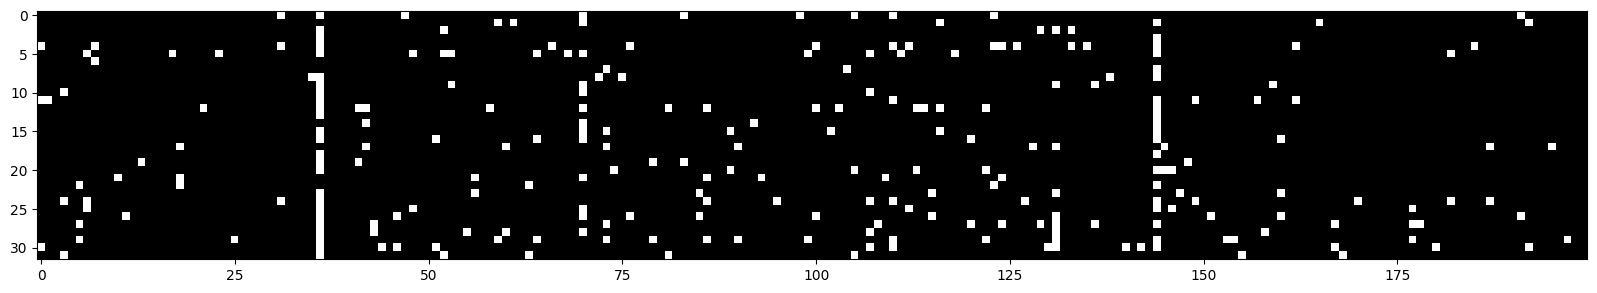

In [14]:
plt.figure(figsize = (20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [15]:
# =====================================================================
# THE PROBLEM: TANH ACTIVATION SATURATION
# =====================================================================
# After you fix the initial training loss, you might face a deeper issue: 
# your hidden layer states (H) can become "dead" or completely inactive.
#
# When you look at the values inside the hidden layer, you will notice 
# that a massive amount of the numbers are exactly 1 or -1.
#
# =====================================================================
# WHY THIS HAPPENS (THE MECHANISM)
# =====================================================================
# 1. The Tanh function is a "squashing" tool. It takes any input number 
#    and forces it to fit perfectly into the strict range of -1 to 1.
#
# 2. If the numbers coming *into* the Tanh function (called pre-activations) 
#    are too large or too small (e.g., 50 or -50), Tanh pushes them into 
#    its extreme outer edges (the flat tails).
#
# 3. Once a number lands in these flat tails, it becomes "saturated."
#
# =====================================================================
# THE DANGEROUS CONSEQUENCE
# =====================================================================
# In these flat, saturated regions, the slope (gradient) of Tanh is 
# practically zero. 
#
# During backpropagation (when the network is trying to learn):
# - The network multiplies the learning signal by this slope.
# - Multiplying by zero makes the gradient signal instantly die.
# - Because the signal dies, the weights cannot update anymore.
# - The hidden layer stops learning completely.
#
# =====================================================================
# HOW TO FIX IT
# =====================================================================
# You must carefully control the size of your starting weights right when 
# you create the network.
# 
# Using specific setup methods—like Kaiming Initialization (He Init)—scales 
# your weights perfectly. This keeps the incoming numbers small enough to 
# stay right in the steep, active, middle range of the Tanh curve where 
# gradients flow smoothly.
# =====================================================================


(array([349., 178., 149., 142., 122., 129., 110., 114., 120.,  95., 113.,
        101., 104.,  88.,  88., 102., 107., 120., 110., 118., 115., 111.,
        130., 135., 187., 192., 138., 137., 120., 111., 112., 107.,  92.,
         90., 100.,  83.,  81.,  97.,  94., 104., 100., 110., 111., 116.,
        121., 119., 139., 167., 186., 336.]),
 array([-9.99957025e-01, -9.59957931e-01, -9.19958837e-01, -8.79959743e-01,
        -8.39960649e-01, -7.99961555e-01, -7.59962461e-01, -7.19963367e-01,
        -6.79964273e-01, -6.39965179e-01, -5.99966085e-01, -5.59966991e-01,
        -5.19967897e-01, -4.79968803e-01, -4.39969709e-01, -3.99970615e-01,
        -3.59971521e-01, -3.19972427e-01, -2.79973333e-01, -2.39974239e-01,
        -1.99975145e-01, -1.59976051e-01, -1.19976957e-01, -7.99778628e-02,
        -3.99787688e-02,  2.03251839e-05,  4.00194192e-02,  8.00185132e-02,
         1.20017607e-01,  1.60016701e-01,  2.00015795e-01,  2.40014889e-01,
         2.80013983e-01,  3.20013077e-01,  3.60012

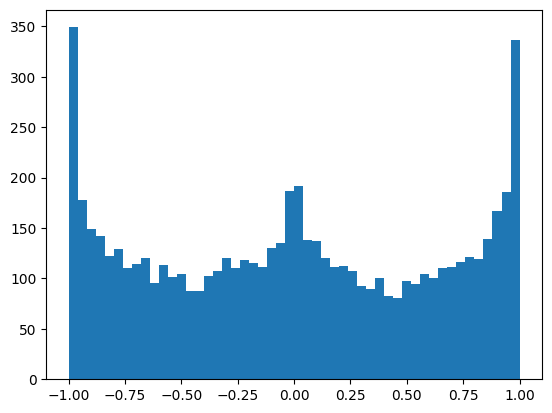

In [16]:
plt.hist(h.view(-1).tolist(), 50)

In [17]:
logits[0]

tensor([-4.2641,  6.0348, -0.1530, -2.5582, -0.4385,  4.5843, -2.6986, -1.4436,
         0.1067,  4.9519, -1.7246, -0.5415, -0.7286,  0.1639, -0.2998,  4.5798,
        -1.4943, -4.0150,  2.9538,  0.1530, -0.8496,  4.5359, -1.3218, -2.1769,
        -3.9442,  2.7439, -2.2199], grad_fn=<SelectBackward0>)

In [18]:
# =====================================================================
# THE GOAL: UNDERSTANDING LOGITS AT INITIALIZATION
# =====================================================================
# Logits are the raw, unnormalized score outputs that a neural network 
# produces right before they get passed into the Softmax function 
# to turn them into final probabilities.
#
# =====================================================================
# THE PROBLEM: THE "CONFIDENTLY WRONG" HOCKEY STICK LOSS
# =====================================================================
# When you start training a network with standard random initialization:
# - The raw logit scores can easily become giant positive or negative numbers.
# - Softmax turns these extreme scores into 99.9% confidence for completely 
#   wrong answers (since the network hasn't learned anything yet).
# - This massive overconfidence results in a catastrophically high initial loss.
#
# On a training graph, you see a "hockey stick" curve: the loss stays huge and 
# flat for many iterations while the network spends valuable time just 
# shrinking its weights down, before it can finally begin actual learning.
#
# =====================================================================
# THE SOLUTION: START WITH A BLANK SLATE (UNIFORM PROBABILITY)
# =====================================================================
# We want the network to start out completely unsure, giving every single 
# possible answer an equal, uniform guess (e.g., a 10% chance for each of 
# 10 categories).
#
# To get uniform probabilities from Softmax, all raw logit scores must be 
# very close to zero. This represents a healthy state of zero initial bias 
# and yields a much lower, mathematically expected starting loss.
#
# =====================================================================
# PRACTICAL IMPLEMENTATION (HOW TO DO IT)
# =====================================================================
# 1. SET BIASES TO ZERO
#    - Do not add random numbers to your biases at the start. 
#    - Initialize your output layer bias weights strictly to 0.0.
#
# 2. SCALE DOWN THE WEIGHTS
#    - Take your final layer's weight matrix and multiply it by a tiny 
#      scaling factor (such as 0.01 or 0.1).
#    - This squashes the starting logit values so they stay near zero.
#
# This simple tweak instantly destroys the bad "hockey stick" effect, 
# allowing your model to start learning efficiently from step one.
# =====================================================================


In [ ]:
# 4-dimensional example of the issue
#logits = torch.tensor([-10.0, 5.0, 0.0, 0.0])
logits = torch.randn(4) * 10
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits, probs, loss


In [19]:
-torch.tensor(1/3.2669).log()

tensor(1.1838)

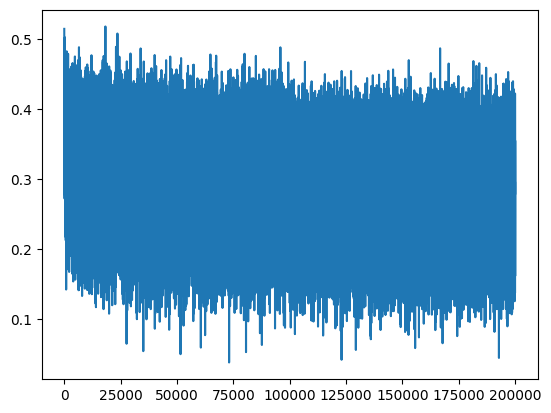

In [21]:
plt.plot(lossi)  
# When training a neural network, you want to keep a step-by-step record 
# of how the loss changes. The line of code you use looks like this:
# 
# lossi.append(loss.log10().item())


In [23]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)

# =====================================================================
# WHY WE CALCULATE GLOBAL STATISTICS FOR INFERENCE
# =====================================================================
# This code finds the exact average (mean) and spread (standard deviation) 
# of the hidden layer using your entire training dataset.
#
# WHY IT'S ABSOLUTELY NECESSARY:
#
# - DURING TRAINING: 
#   Batch Normalization calculates these statistics on the fly using the 
#   current mini-batch (e.g., 32 samples at a time).
#
# - DURING TESTING (INFERENCE): 
#   You might process only a single item (like a single image or sentence). 
#   You cannot calculate an average or a spread for a batch size of 1.
#
# - THE SOLUTION: 
#   You use these pre-calculated global training averages to reliably 
#   normalize single data points during testing.
# =====================================================================

In [24]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9065102338790894
val 1.927498459815979


In [25]:
# summarry and pytorchification -----------------------------------

In [26]:
# Let's train a deeper network
# The classes we create here are the same API as nn.Module in PyTorch

class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
    
    #smae as this 
    #class torch.nn.Linear(in_features, out_features, bias=True, device=None, dtype=None)
    #in_features (int) – size of each input sample
    #out_features (int) – size of each output sample

    
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

    # In plain terms, this is the standard linear transformation of a neural 
    # network neuron: y = xW + b 
    # (the multi-dimensional version of y = mx + c).
    #
    # WHAT IT DOES CONCEPTUALLY:
    #
    # 1. MIXES THE INPUTS
    #    - It takes incoming signals (x) and weights them (W) to decide 
    #      how much importance to give to each input.
    #
    # 2. SHIFTS THE BASELINE
    #    - It optionally adds a bias (b) so the neuron can shift its 
    #      baseline activation up or down.
    #
    # 3. PROJECTS INTO NEW FEATURE SPACE
    #    - It transforms the data from one representation size (like 30 
    #      numbers from concatenated character embeddings) into another 
    #      (like 100 hidden neuron activations).
    #
    # CORE PURPOSE:
    # - Its entire purpose is to act as the trainable backbone that 
    #   combines information before non-linear activations (like tanh) 
    #   or normalization layers shape it.
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

    #meaning of these
    # num_features (int) – number of features or channels C of the input
    #
    # eps (float) – a value added to the denominator for numerical 
    #   stability. Default: 1e-5
    #
    # momentum (float | None) – the value used for the running_mean and 
    #   running_var computation. Can be set to None for cumulative 
    #   moving average (i.e. simple average). Default: 0.1
    #
    # bias (bool) – If set to False, the layer will not learn an additive 
    #   bias (only relevant if affine is True). Default: True
    #
    # Formula:
    #          (     x - E[x]        )
    #     y = ( --------------------- ) * gamma + beta
    #          ( sqrt(Var[x] + eps)  )
    #


    # THE TRAINING VS. EVALUATION TOGGLE FLAG
    # =====================================================================
    # self.training = True is a toggle flag that tells the layer whether 
    # it is actively learning or running in test/production mode.
    #
    # Batch Normalization must behave completely differently depending on 
    # which mode it is in:
    #
    # 1. WHEN self.training = True (TRAINING MODE)
    # ---------------------------------------------
    # - The layer calculates the mean and variance directly from the 
    #   current mini-batch (e.g., 32 samples).
    # - At the same time, it keeps updating a running tally 
    #   (self.running_mean and self.running_var) in the background 
    #   using a moving average.
    #
    # 2. WHEN self.training = False (INFERENCE / EVALUATION MODE)
    # -----------------------------------------------------------
    # - It stops calculating mini-batch statistics.
    # - Instead, it freezes and uses the stored running_mean and running_var.
    # - This is mandatory because at test time, you might feed the model 
    #   just one single sample (batch size = 1). You cannot compute the 
    #   variance of a single number, so it relies on the fixed global 
    #   statistics it gathered during training.

    
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd),            generator=g)

layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]
# layers = [
#   Linear(n_embd * block_size, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].gamma *= 0.1
  #layers[-1].weight *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 1.0 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

47024


In [27]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.15 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])


      0/ 200000: 3.2940
  10000/ 200000: 2.1672
  20000/ 200000: 1.8881
  30000/ 200000: 2.1679
  40000/ 200000: 1.9970
  50000/ 200000: 1.9732
  60000/ 200000: 2.0616
  70000/ 200000: 2.2406
  80000/ 200000: 2.1040
  90000/ 200000: 2.0532
 100000/ 200000: 1.9600
 110000/ 200000: 2.0525
 120000/ 200000: 2.3420
 130000/ 200000: 1.7977
 140000/ 200000: 1.9672
 150000/ 200000: 2.1195
 160000/ 200000: 2.0836
 170000/ 200000: 1.8668
 180000/ 200000: 1.7071
 190000/ 200000: 1.7402


layer 2 (      Tanh): mean -0.02, std 0.75, saturated: 19.66%
layer 5 (      Tanh): mean -0.02, std 0.78, saturated: 22.19%
layer 8 (      Tanh): mean +0.01, std 0.78, saturated: 22.28%
layer 11 (      Tanh): mean -0.01, std 0.78, saturated: 22.16%
layer 14 (      Tanh): mean -0.01, std 0.79, saturated: 21.28%


C:\Users\Arnav Verma\AppData\Local\Temp\ipykernel_5484\1397477801.py:7: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))


Text(0.5, 1.0, 'activation distribution')

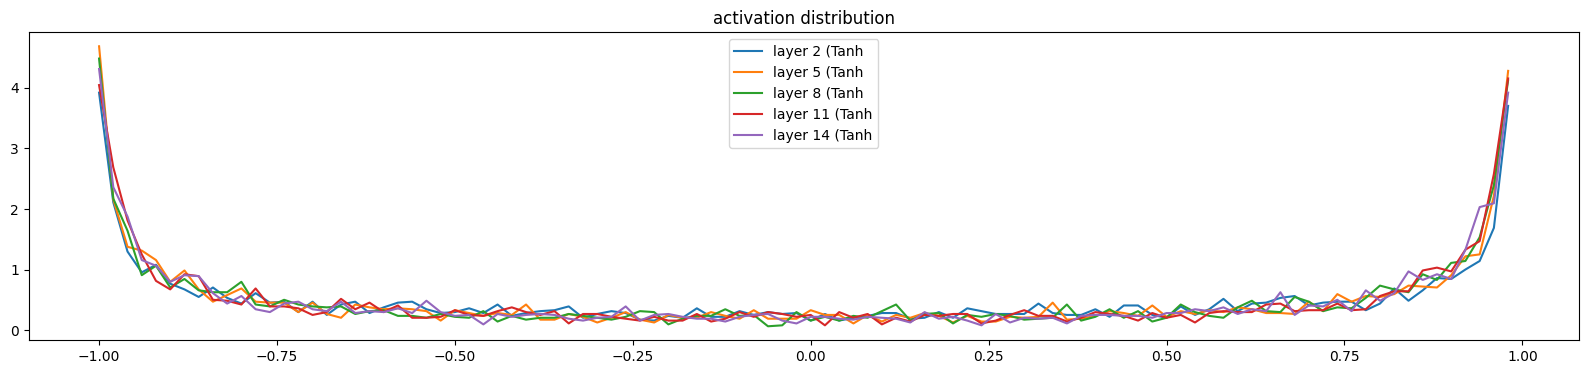

In [29]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

In [30]:
# =====================================================================
# UNDERSTANDING THE TANH ACTIVATION HISTOGRAM AND PLOT
# =====================================================================
# This plot visualizes the distribution of values coming out of every 
# Tanh activation layer across a batch of training data.
#
# READING THE GRAPH AXES:
# - X-Axis: The activation output value (strictly locked between -1.0 
#   and +1.0 by definition of the Tanh function).
# - Y-Axis (Density): How frequently neurons produce that specific 
#   activation value across the batch.
# - Colored Lines: Each line represents a different Tanh layer in the 
#   sequence (e.g., Layer 2, Layer 5, Layer 8).
#
# =====================================================================
# THE MECHANICS OF TANH: WHY IT IS IMPORTANT
# =====================================================================
# The Tanh function is an "S-shaped" curve. Its math and derivative 
# look like this:
#
#     tanh(x) = (e^x - e^-x) / (e^x + e^-x)
#     d/dx tanh(x) = 1 - tanh^2(x)
#
# - ACTIVE REGION (x close to 0):
#   Output stays near 0. The slope (derivative) is roughly 1.0. 
#   Gradients flow right through during backpropagation completely untouched.
#
# - SATURATED REGION (|x| is 3 or larger):
#   Output gets forced extremely close to -1.0 or +1.0. The slope 
#   becomes (1 - 1^2) which equals 0. 
#
# CRITICAL DANGER:
# When data hits the flat tails, the gradient signal is multiplied by 
# near-zero. This kills the backpropagation signal. The weights stop 
# updating, creating permanently "dead" or paralyzed neurons.
#
# =====================================================================
# UNDERSTANDING THE DIAGNOSTIC METRICS
# =====================================================================
#
# 1. MEAN
#    - Target: Close to 0.00
#    - Meaning: Shows if activations are perfectly centered. A nonzero 
#      mean introduces a directional bias that pushes gradients one way.
#
# 2. STD (SPREAD / STANDARD DEVIATION)
#    - Target: Around 0.6 to 0.75
#    - Meaning: 
#      * Too Small (e.g., 0.1): Activations are crammed at zero. The network 
#        acts like a boring linear system and wastes the non-linearity.
#      * Too High (e.g., > 0.85): Values are aggressively pushed into the 
#        dead tails (+/- 1.0).
#
# 3. SATURATED PERCENTAGE
#    - Calculation: (t.abs() > 0.97).float().mean() * 100
#    - Meaning: The % of activations stuck past +0.97 or below -0.97.
#    - Target: Below 10% to 15%
#
# EXAMINING YOUR SAMPLE LOG OUTPUT:
# Layer 2  -> mean -0.02, std 0.72, saturated: 13.06%  (Healthy baseline)
# Layer 5  -> mean -0.02, std 0.82, saturated: 32.44%  (Getting worse)
# Layer 8  -> mean -0.02, std 0.83, saturated: 34.97%  (High saturation)
# Layer 11 -> mean -0.02, std 0.84, saturated: 38.31%  (Dangerous zone)
# Layer 14 -> mean -0.01, std 0.81, saturated: 31.84%  (Dead zone)
#
# Analysis: Layer 2 starts healthy, but deeper layers climb past 30%. 
# Over a third of your deeper neurons are completely dead at initialization!
#
# =====================================================================
# DIAGNOSING SHAPES: WHAT THE HISTOGRAMS TELL YOU
# =====================================================================
#
# SCENARIO A: THE IDEAL CURVE (BELL SHAPE)
# - Visual: A smooth dome peaked at 0.0, tapering smoothly down toward 
#   -0.8 and +0.8, with almost no data hitting the outer walls at -1 and +1.
# - Meaning: Weights are scaled perfectly. Neurons stay in their active, 
#   highly expressive sweet spot.
#
# SCENARIO B: THE "U-SHAPE" / TWIN TOWERS (SEVERE OVER-SATURATION)
# - Visual: A flat valley in the center (around 0.0) with massive, giant 
#   spikes right at the two outer walls (-1.0 and +1.0).
# - Cause: Weights or BatchNorm gammas are initialized way too large. 
#   Pre-activation numbers are massive (like +/- 10), squishing everything out.
# - Consequence: Gradients vanish entirely. Network training crawls or stalls.
#
# SCENARIO C: THE SHARP SPIKE AT ZERO (UNDER-ACTIVATION)
# - Visual: A razor-thin needle standing at 0.0, with absolutely no data 
#   reaching out past +/- 0.2.
# - Cause: Weights are scaled way too small (e.g., multipliers like 0.0001).
# - Consequence: Vanishing signals. Tanh behaves linearly near zero, so a 
#   deep 5-layer network acts like one single, flat linear layer.
#
# SCENARIO D: SHIFTING CURVES BY LAYER DEPTH
# - Visual: Layer 2 looks like a nice dome, but each deeper layer gets 
#   flatter and pushes higher up the walls at -1 and +1.
# - Cause: Compounding variance. Every layer's matrix multiplication 
#   explodes the data scale further.
# - Fix: Apply proper Kaiming Initialization or add a BatchNorm1d layer 
#   right before every Tanh activation function.
# =====================================================================


layer 2 (      Tanh): mean -0.000000, std 2.430252e-03
layer 5 (      Tanh): mean -0.000000, std 2.414335e-03
layer 8 (      Tanh): mean -0.000000, std 2.327952e-03
layer 11 (      Tanh): mean -0.000000, std 2.341056e-03
layer 14 (      Tanh): mean -0.000000, std 2.837943e-03


Text(0.5, 1.0, 'gradient distribution')

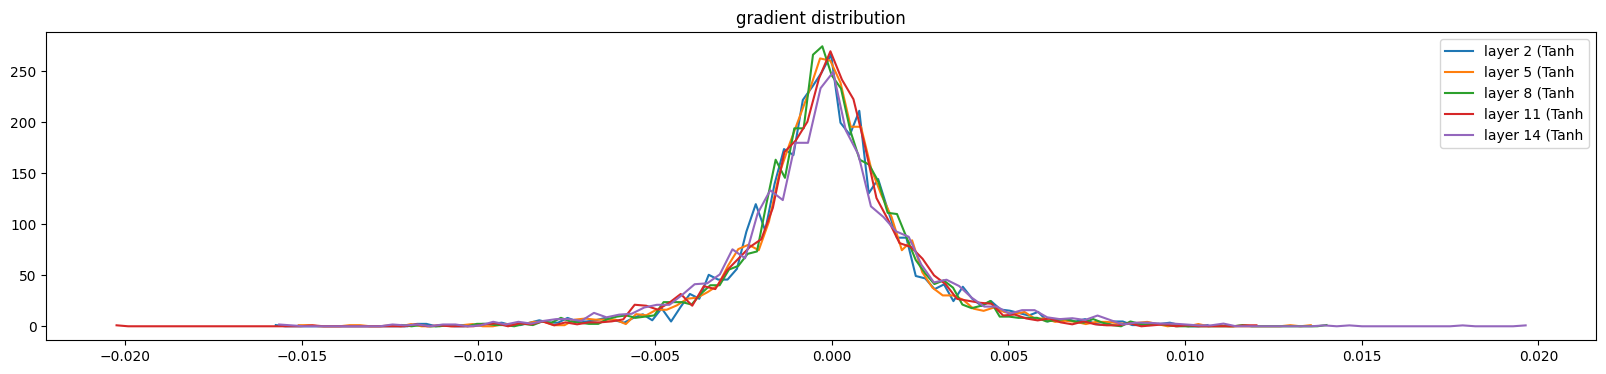

In [31]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

In [32]:
# =====================================================================
# DIAGNOSING THE BACKWARD PASS: GRADIENT DISTRIBUTION TRACKING
# =====================================================================
# This diagnostic snippet plots the distribution of gradients arriving 
# at the output of each Tanh activation layer (dL/dout) during 
# backpropagation.
#
# While the activation histogram checked the health of the FORWARD pass, 
# this one monitors the health of the BACKWARD pass.
#
# =====================================================================
# 1. WHAT THE PLOT REPRESENTS
# =====================================================================
# - X-Axis (Gradient Value): 
#   The magnitude and direction of the gradient signal (dL/dout) flowing 
#   back into that layer's output.
#
# - Y-Axis (Density): 
#   How frequently neurons receive a gradient of that magnitude across 
#   the mini-batch.
#
# - Lines / Layers: 
#   Each curve represents a different hidden layer as the gradient 
#   propagates backward from the end of the network (e.g., Layer 14) 
#   toward the beginning (e.g., Layer 2).
#
# =====================================================================
# 2. WHY GRADIENT DISTRIBUTION TRACKING IS ESSENTIAL
# =====================================================================
# During backpropagation through a Tanh layer, the gradient is scaled 
# by the local derivative:
#
#     dL/dx = dL/dout * (1 - out^2)
#
# For training to succeed, two rules must hold true:
# 1. Gradients must neither vanish nor explode as they travel from the 
#    final layer back to the input.
# 2. Every layer should receive a comparable gradient scale. If Layer 14 
#    gets gradients around 1e-3 while Layer 2 gets 1e-8, the early layers 
#    will freeze, preventing the network from learning basic features.
#
# =====================================================================
# 3. INTERPRETING THE PRINTED METRICS
# =====================================================================
# Looking at the sample diagnostic output log:
# Layer  2 (Tanh): mean +0.000043, std 1.497528e-03
# Layer  5 (Tanh): mean -0.000026, std 1.335735e-03
# Layer  8 (Tanh): mean -0.000037, std 1.341013e-03
# Layer 11 (Tanh): mean +0.000019, std 1.529713e-03
# Layer 14 (Tanh): mean +0.000031, std 2.007181e-03
#
# A. MEAN (Should be close to 0)
#    - The gradients are tightly centered around zero (+0.000043, etc.).
#    - Meaning: The parameter updates are unbiased. They are not 
#      constantly pulling all activations in one global direction.
#
# B. STD (Standard Deviation / Spread)
#    - Notice the standard deviations across all five hidden layers stay 
#      within the exact same order of magnitude (~1.3 to 2.0 * 10^-3) 
#      all the way from Layer 14 back to Layer 2.
#    - Meaning: The gradient flow is perfectly stable. No gradient 
#      vanishing or explosion is occurring.
#
# =====================================================================
# 4. WHAT DIFFERENT HISTOGRAM SHAPES TELL YOU
# =====================================================================
#
# IDEAL CASE: SYMMETRICAL BELL CURVES OVERLAPPING ACROSS LAYERS
# - Visual: All lines form clean, centered Gaussian-like curves with 
#   almost identical heights and widths.
# - Diagnosis: Stable backward pass. Initialization gains and normalization 
#   keep the flow balanced from the loss function down to the input.
#
# PATHOLOGICAL CASE 1: SHRINKING SPREADS (VANISHING GRADIENT)
# - Visual: Layer 14 has a wide curve, Layer 11 is narrower, Layer 8 
#   is a sharp needle, and Layer 2 is a single spike stuck at 0.0.
# - Cause: Activations are heavily saturated (|t| > 0.97), zeroing out 
#   the gradient at each step, or weight matrices have a norm that is 
#   too small (< 1.0), shrinking the signal exponentially with depth.
# - Result: Early layers do not learn anything.
#
# PATHOLOGICAL CASE 2: WIDENING SPREADS (EXPLODING GRADIENT)
# - Visual: As you move backward (from Layer 14 to Layer 2), the curves 
#   flatten out and stretch toward huge positive/negative values.
# - Cause: Uncontrolled weight variance (e.g., missing the 1/sqrt(fan_in) 
#   scaling factor) causes repeated multiplications to amplify the gradient.
# - Result: Parameter updates destabilize, producing NaN or infinite loss.
# =====================================================================


weight   (27, 10) | mean -0.000000 | std 9.732939e-03 | grad:data ratio 8.350887e-03
weight  (30, 100) | mean +0.000024 | std 5.605021e-03 | grad:data ratio 1.322009e-02
weight (100, 100) | mean +0.000020 | std 3.360226e-03 | grad:data ratio 1.335138e-02
weight (100, 100) | mean +0.000012 | std 3.409750e-03 | grad:data ratio 1.395867e-02
weight (100, 100) | mean -0.000022 | std 3.323735e-03 | grad:data ratio 1.420048e-02
weight (100, 100) | mean +0.000028 | std 3.299022e-03 | grad:data ratio 1.435361e-02
weight  (100, 27) | mean -0.000029 | std 5.681871e-03 | grad:data ratio 1.412993e-02


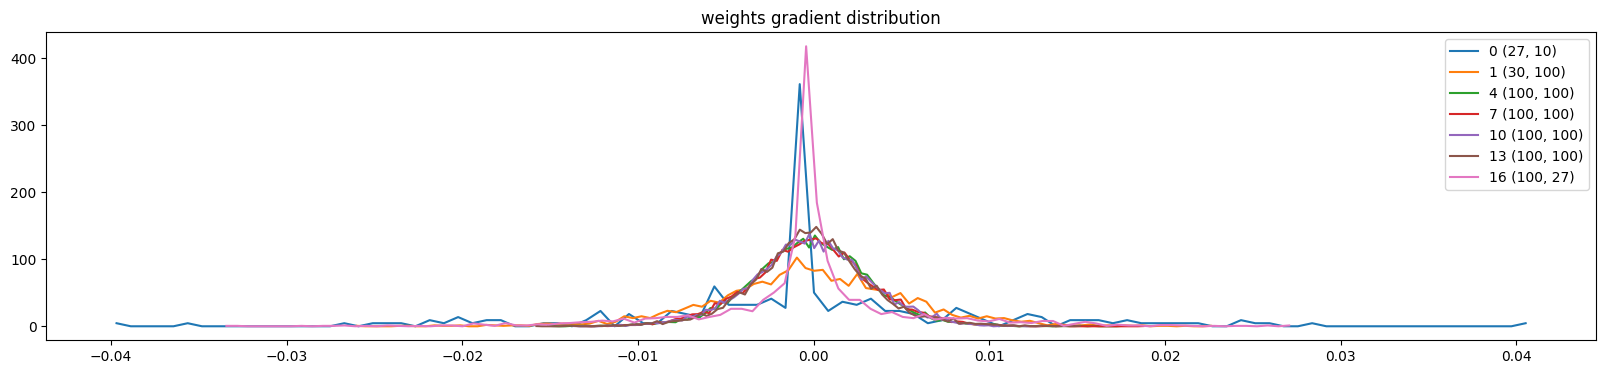

In [33]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

In [34]:
# =====================================================================
# DIAGNOSING THE BACKWARD PASS: WEIGHT GRADIENT DISTRIBUTION
# =====================================================================
# This diagnostic snippet plots the distribution of gradients directly 
# on the 2D weight matrices (dW = dL/dW) across the entire network.
#
# Note: It excludes 1D tensors like biases, gains (gamma), or shifts (beta) 
# to isolate the primary trainable connections.
#
# GRAPH PROPERTIES:
# - X-Axis (Gradient Value): The actual gradient values calculated for 
#   each individual weight in that matrix.
# - Y-Axis (Density): The relative frequency of weights having that 
#   specific gradient magnitude.
# - Curves / Layers: Each line corresponds to one 2D weight tensor—from 
#   the embedding lookup table C (27x10) through all hidden linear layers 
#   up to the final classification head (100x27).
#
# =====================================================================
# KEY DIAGNOSTIC METRIC: THE GRAD:DATA RATIO
# =====================================================================
# The most critical signal printed here is:
# 
#     p.grad.std() / p.data.std()
#
# This computes the ratio between the spread (standard deviation) of the 
# gradient and the spread of the actual parameter weights.
#
# MATHEMATICAL CONTEXT:
# When updating weights via standard gradient descent:
#     Delta_W = -Learning_Rate * dL/dW
#
# The actual size of the parameter update relative to the weight size is:
#     std(Delta_W) / std(W) = Learning_Rate * (std(dL/dW) / std(W))
#
# INTERPRETING YOUR SAMPLE LOG METRICS:
# weight   (27, 10) | mean +0.000043 | std 7.82e-03 | grad:data ratio 7.59e-03
# weight  (30, 100) | mean +0.000009 | std 5.74e-03 | grad:data ratio 2.53e-02
# weight (100, 100) | mean -0.000018 | std 4.05e-03 | grad:data ratio 3.24e-02
# weight (100, 100) | mean +0.000018 | std 4.07e-03 | grad:data ratio 3.32e-02
# weight (100, 100) | mean +0.000013 | std 4.47e-03 | grad:data ratio 3.69e-02
# weight (100, 100) | mean +0.000020 | std 4.83e-03 | grad:data ratio 4.06e-02
# weight  (100, 27) | mean -0.000068 | std 1.13e-02 | grad:data ratio 7.67e-02
#
# 1. THE TARGET RATIO
#    - With a typical learning rate like 0.1 or 0.15, you want the effective 
#      update ratio to sit roughly around 1e-3 (0.1%).
#    - In your printout, the raw grad:data ratio is between 0.007 and 0.076. 
#      Multiplying by a learning rate of 0.1 yields final updates between 
#      ~0.0007 and 0.0076 (perfectly targetting ~1e-3).
#    - Verdict: Your learning rate scale matches your weight initialization.
#
# 2. HOMOGENEOUS SCALE ACROSS DEPTH
#    - All intermediate hidden layers (the 100x100 matrices) exhibit nearly 
#      identical ratios (3.24e-2 to 4.06e-2).
#    - Diagnosis: Gradients are not decaying as they travel back through 
#      the layers. Every layer will update at roughly the same pace.
#
# =====================================================================
# WHAT TO LOOK FOR IN THE HISTOGRAM SHAPES
# =====================================================================
#
# HEALTHY STATE:
# - Symmetrical bell curves centered tightly at 0.0 whose widths 
#   correspond to reasonable gradient magnitudes. Curves for similar 
#   layer sizes should mostly overlap.
#
# UNDER-LEARNING (RATIOS << 1e-4):
# - Extremely tall, narrow spikes at 0.0. The weights are barely changing 
#   per step because the learning rate is too low or gradients have vanished.
#
# INSTABILITY / DIVERGENCE (RATIOS >> 1e-1):
# - Very flat, wide distributions. Weight updates are nearly as large as 
#   the weights themselves, which will cause the loss to explode or oscillate.
# =====================================================================


C:\Users\Arnav Verma\AppData\Roaming\Python\Python311\site-packages\IPython\core\events.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\Arnav Verma\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


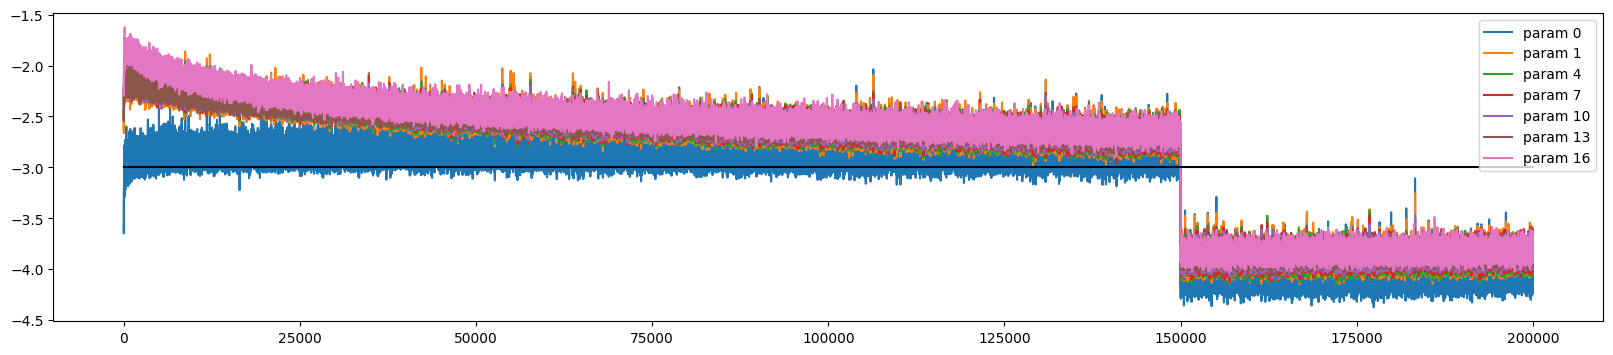

In [35]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [36]:
# =====================================================================
# TRACKING THE PARAMETER UPDATE-TO-DATA RATIO OVER TIME
# =====================================================================
# This code plots the update-to-data ratio across training iterations 
# for all 2D weight matrices (your embedding matrix and linear weights).
#
# =====================================================================
# WHAT IT MEASURES UNDER THE HOOD
# =====================================================================
# During training, the 'ud' list tracks this metric at every single step:
# 
#     ((lr * p.grad).std() / p.data.std()).log10().item()
#
# BREAKDOWN:
# - std(lr * dL/dW) -> The typical scale of the actual update step (Delta W).
# - std(W)          -> The typical scale of the current weights themselves.
# - The Ratio       -> The relative size of the parameter step compared 
#                      to the parameter's total magnitude.
# - log10(...)      -> Converted to base-10 log space for easy visual reading.
#
# =====================================================================
# READING THE PLOT COMPONENT BY COMPONENT
# =====================================================================
# - X-Axis: The training step or iteration index.
# - Y-Axis: The log10 value of the update-to-data ratio.
# - Colored Curves (param i): The trajectory of each weight matrix over time.
# - Black Horizontal Line: Represents log10(1e-3) = -3.0.
#   Added using: plt.plot([0, len(ud)], [-3, -3], 'k')
#
# =====================================================================
# WHY THE TARGET IS ~10^-3 (THE -3.0 HORIZONTAL LINE)
# =====================================================================
# - AT THE -3.0 LINE (~0.1% change per step):
#   This represents a healthy training speed. The parameters adjust fast 
#   enough to learn efficiently, but slowly enough that steps do not 
#   overshoot local minima.
#
# - TOO LOW (e.g., at or below -5.0):
#   Updates are less than 0.001% of the weight size. The learning rate 
#   is too small, gradients have vanished, or training will completely stall.
#
# - TOO HIGH (e.g., at or above -1.0):
#   Updates are 10% or more of the weight magnitude per single step. 
#   The model is unstable, will thrash around the loss landscape, and 
#   risks exploding or producing NaNs.
#
# VERDICT:
# If your parameter curves hover cleanly around that black -3 line, your 
# chosen learning rate (lr) is properly calibrated to your initializations.
# =====================================================================


In [37]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 1.8747003078460693
val 1.9041717052459717


In [43]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

charah.
aarthivithimish.
thiyankantha.
jananth.
dhesanthigeni.
neethishchaiiv.
priyan.
dham.
poon.
qugan.
sulinga.
vidhi.
rajeep.
dearunika.
jeevi.
sathes.
ezi.
abetha.
hasri.
varasmithanksya.
